In [2]:
from langchain_openrouter import ChatOpenRouter
import getpass
import os
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv()

if not os.getenv("OPENROUTER_API_KEY"):
    os.environ["OPENROUTER_API_KEY"] = getpass.getpass("Enter your OpenRouter API key: ")

if not os.getenv("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")


model = ChatOpenRouter(
    model="openai/gpt-3.5-turbo",
    max_tokens=400,
    # reasoning={'effort': 'minimal'}
)

/home/apurv.panchal@simform.dom/Documents/langgraph-learning/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Intro

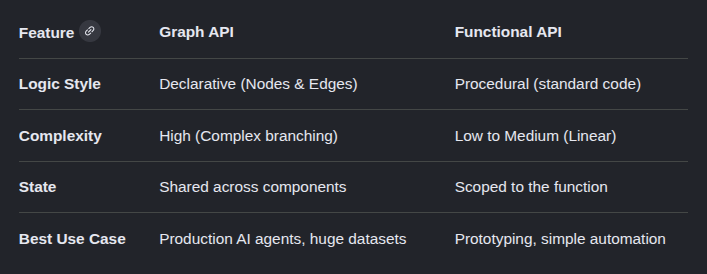

#### Using Graph API

In [14]:
# 1. Define tools and model
from langchain.tools import tool
from langchain.chat_models import init_chat_model

@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

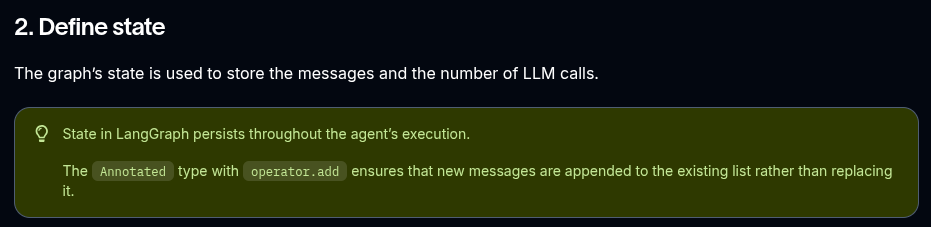

In [15]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

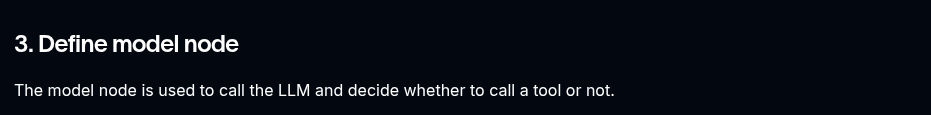

In [16]:
from langchain.messages import SystemMessage

def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        'messages': [
            model_with_tools.invoke(
                [
                    SystemMessage(content='You are a helpful assistant tasked with performing arithmetic on a set of inputs.')
                ]
                + state['messages']
            )
        ],
        'llm_calls': state.get('llm_calls',0) + 1
    }

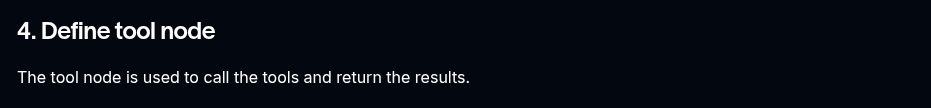

In [17]:
from langchain.messages import ToolMessage

def tool_node(state: dict):
    """Perform the tool call"""

    result = []
    for tool_call in state['messages'][-1].tool_calls:
        tool = tools_by_name[tool_call['name']]
        observation = tool.invoke(tool_call['args'])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call['id']))
    return {'messages': result}

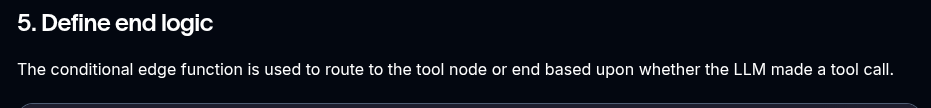

In [18]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

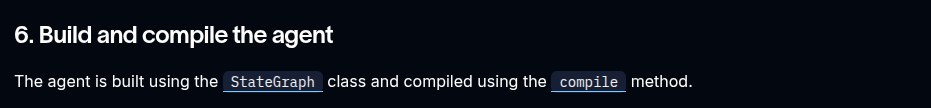

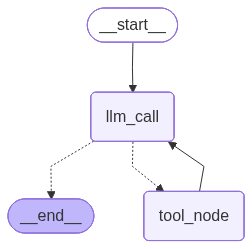

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_bBNHKDPbLq7CjJ3jwTxBPrT6)
 Call ID: call_bBNHKDPbLq7CjJ3jwTxBPrT6
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [19]:
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

#### Using Functional API

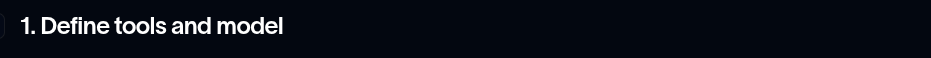

In [20]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

from langgraph.graph import add_messages
from langchain.messages import (
    SystemMessage,
    HumanMessage,
    ToolCall,
)
from langchain_core.messages import BaseMessage
from langgraph.func import entrypoint, task

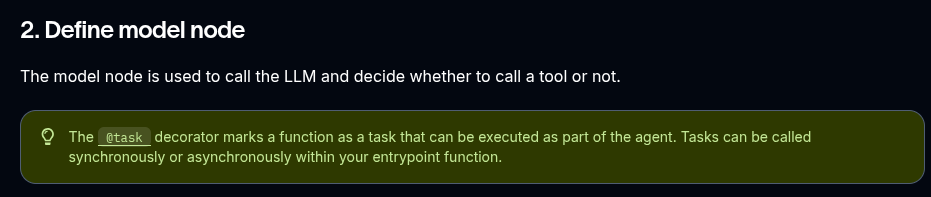

In [21]:
@task
def call_llm(messages: list[BaseMessage]):
    """LLM decides whether to call a tool or not"""
    return model_with_tools.invoke(
        [
            SystemMessage(
                content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
            )
        ]
        + messages
    )

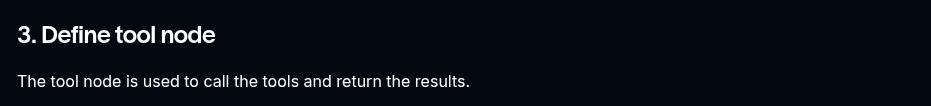

In [22]:
@task
def call_tool(tool_call: ToolCall):
    """Perform the tool call"""
    tool = tools_by_name[tool_call['name']]
    return tool.invoke(tool_call)

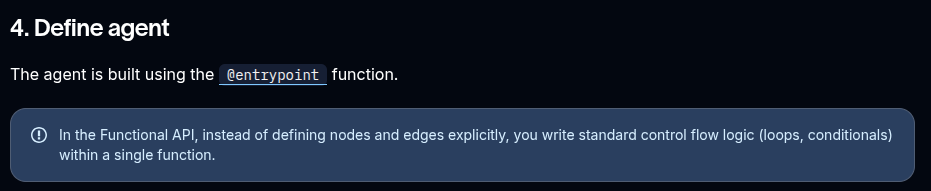

In [23]:
@entrypoint()
def agent(messages: list[BaseMessage]):
    model_response = call_llm(messages).result()

    while True:
        if not model_response.tool_calls:
            break

        tool_result_futures = [call_tool(tool_call) for tool_call in model_response.tool_calls]
        tool_results = [fut.result() for fut in tool_result_futures]
        messages = add_messages(messages, [model_response, *tool_results])
        model_response = call_llm(messages).result()

    messages = add_messages(messages, model_response)
    return messages

messages = [HumanMessage(content='Add 3 and 4.')]
for chunk in agent.stream(messages, stream_mode='updates'):
    print(chunk)
    print('\n')

{'call_llm': AIMessage(content='', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-3.5-turbo', 'id': 'gen-1779351709-3ZzLKcygotS9tVgSGnnG', 'created': 1779351709, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter'}, id='lc_run--019e49a0-6460-7540-bc72-875fb826f4c3-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_rbFYIqLdSjOioWePrk4fH2hZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 171, 'output_tokens': 17, 'total_tokens': 188, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 0}})}


{'call_tool': ToolMessage(content='7', name='add', tool_call_id='call_rbFYIqLdSjOioWePrk4fH2hZ')}


{'call_llm': AIMessage(content='The sum of 3 and 4 is 7.', additional_kwargs={}, response_metadata={'model_name': 'openai/gpt-3.5-turbo', 'id': 'gen-1779351710-GBOfuCLF1GySYaCcRenn', 'created': 1779351710, 'object': 'chat.compl

### Thinking in LangGraph

In [31]:
# Define State
from typing import TypedDict, Literal

class EmailClassification(TypedDict):
    intent: Literal['question','bug','billing','feature','complex']
    urgency: Literal['low','medium','high','critical']
    topic: str
    summary: str

class EmailAgentState(TypedDict):
    email_content: str
    sender_email: str
    email_id: str

    classification: EmailClassification | None

    search_results: list[str] | None
    customer_history: dict | None

    draft_response: str | None
    messages: list[str] | None


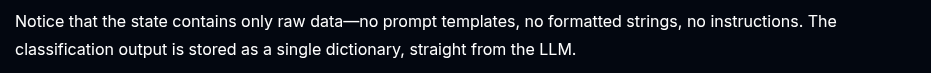

- Read and Classify nodes

In [32]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command, RetryPolicy
from langchain.messages import HumanMessage

llm = model

def read_email(state: EmailAgentState) -> dict:
    """Extract and parse email content"""

    return {
        "messages": [HumanMessage(content=f"Processing email: {state['email_content']}")]
    }

def classify_intent(state: EmailAgentState) -> Command[Literal["search_documentation", "human_review", "draft_response", "bug_tracking"]]:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns EmailClassification dict
    structured_llm = llm.with_structured_output(EmailClassification)

    # Format the prompt on-demand, not stored in state
    classification_prompt = f"""
    Analyze this customer email and classify it:

    Email: {state['email_content']}
    From: {state['sender_email']}

    Provide classification including intent, urgency, topic, and summary.
    """

    # Get structured response directly as dict
    classification = structured_llm.invoke(classification_prompt)

    # Determine next node based on classification
    if classification['intent'] == 'billing' or classification['urgency'] == 'critical':
        goto = "human_review"
    elif classification['intent'] in ['question', 'feature']:
        goto = "search_documentation"
    elif classification['intent'] == 'bug':
        goto = "bug_tracking"
    else:
        goto = "draft_response"

    # Store classification as a single dict in state
    return Command(
        update={"classification": classification},
        goto=goto
    )

- Search and tracking nodes

In [33]:
def search_documentation(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Search knowledge base for relevant information"""

    # Build search query from classification
    classification = state.get('classification', {})
    query = f"{classification.get('intent', '')} {classification.get('topic', '')}"

    try:
        # Implement your search logic here
        # Store raw search results, not formatted text
        search_results = [
            "Reset password via Settings > Security > Change Password",
            "Password must be at least 12 characters",
            "Include uppercase, lowercase, numbers, and symbols"
        ]
    except SearchAPIError as e:
        # For recoverable search errors, store error and continue
        search_results = [f"Search temporarily unavailable: {str(e)}"]

    return Command(
        update={"search_results": search_results},  # Store raw results or error
        goto="draft_response"
    )

def bug_tracking(state: EmailAgentState) -> Command[Literal["draft_response"]]:
    """Create or update bug tracking ticket"""

    # Create ticket in your bug tracking system
    ticket_id = "BUG-12345"  # Would be created via API

    return Command(
        update={
            "search_results": [f"Bug ticket {ticket_id} created"],
            "current_step": "bug_tracked"
        },
        goto="draft_response"
    )

- Response nodes

In [34]:
def draft_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    """Generate response using context and route based on quality"""

    classification = state.get('classification', {})

    # Format context from raw state data on-demand
    context_sections = []

    if state.get('search_results'):
        # Format search results for the prompt
        formatted_docs = "\n".join([f"- {doc}" for doc in state['search_results']])
        context_sections.append(f"Relevant documentation:\n{formatted_docs}")

    if state.get('customer_history'):
        # Format customer data for the prompt
        context_sections.append(f"Customer tier: {state['customer_history'].get('tier', 'standard')}")

    # Build the prompt with formatted context
    draft_prompt = f"""
    Draft a response to this customer email:
    {state['email_content']}

    Email intent: {classification.get('intent', 'unknown')}
    Urgency level: {classification.get('urgency', 'medium')}

    {chr(10).join(context_sections)}

    Guidelines:
    - Be professional and helpful
    - Address their specific concern
    - Use the provided documentation when relevant
    """

    response = llm.invoke(draft_prompt)

    # Determine if human review needed based on urgency and intent
    needs_review = (
        classification.get('urgency') in ['high', 'critical'] or
        classification.get('intent') == 'complex'
    )

    # Route to appropriate next node
    goto = "human_review" if needs_review else "send_reply"

    return Command(
        update={"draft_response": response.content},  # Store only the raw response
        goto=goto
    )

def human_review(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pause for human review using interrupt and route based on decision"""

    classification = state.get('classification', {})

    # interrupt() must come first - any code before it will re-run on resume
    human_decision = interrupt({
        "email_id": state.get('email_id',''),
        "original_email": state.get('email_content',''),
        "draft_response": state.get('draft_response',''),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "Please review and approve/edit this response"
    })

    # Now process the human's decision
    if human_decision.get("approved"):
        return Command(
            update={"draft_response": human_decision.get("edited_response", state.get('draft_response',''))},
            goto="send_reply"
        )
    else:
        # Rejection means human will handle directly
        return Command(update={}, goto=END)

def send_reply(state: EmailAgentState) -> dict:
    """Send the email response"""
    # Integrate with email service
    print(f"Sending reply: {state['draft_response'][:100]}...")
    return {}

- Graph compilation code

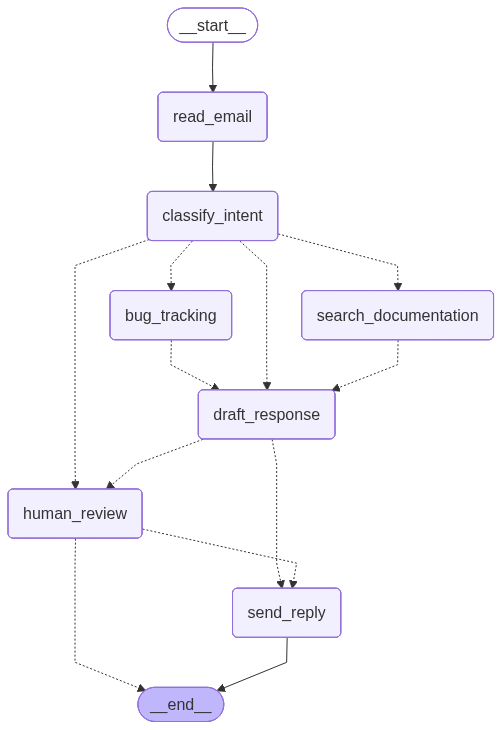

In [35]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import RetryPolicy

# Create the graph
workflow = StateGraph(EmailAgentState)

# Add nodes with appropriate error handling
workflow.add_node("read_email", read_email)
workflow.add_node("classify_intent", classify_intent)

# Add retry policy for nodes that might have transient failures
workflow.add_node(
    "search_documentation",
    search_documentation,
    retry_policy=RetryPolicy(max_attempts=3)
)
workflow.add_node("bug_tracking", bug_tracking)
workflow.add_node("draft_response", draft_response)
workflow.add_node("human_review", human_review)
workflow.add_node("send_reply", send_reply)

# Add only the essential edges
workflow.add_edge(START, "read_email")
workflow.add_edge("read_email", "classify_intent")
workflow.add_edge("send_reply", END)

# Compile with checkpointer for persistence, in case run graph with Local_Server --> Please compile without checkpointer
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

- Testing the agent

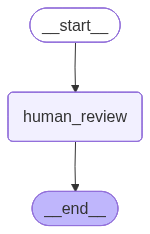

human review interrupt:(Interrupt(value={'approved': False, 'edited_response': 'Draft response'}, id='ea7779d2f7d1d5640dea95a1339232ef'),)


In [36]:
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt


class EmailState(TypedDict):
    email_content: str
    response_text: str | None


def human_review_node(state: EmailState):
    interrupt(
        {
            "approved": False,
            "edited_response": state.get("response_text") or "",
        }
    )
    return {"response_text": "placeholder"}


app = (
    StateGraph(EmailState)
    .add_node("human_review", human_review_node)
    .add_edge(START, "human_review")
    .add_edge("human_review", END)
    .compile(checkpointer=InMemorySaver())
)

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

initial_state = {
    "email_content": "I was charged twice for my subscription! This is urgent!",
    "response_text": "Draft response",
}

# Run with a thread_id for persistence
config = {"configurable": {"thread_id": "customer_1234"}}
result = app.invoke(initial_state, config, version="v2")
# The graph will pause at human_review
print(f"human review interrupt:{result.interrupts}")

In [39]:
human_response = Command(
    resume={
        "approved": True,
        "edited_response": "We sincerely apologize for the double charge. I've initiated an immediate refund...",
    }
)

# Resume execution
final_result = app.invoke(human_response, config, version="v2")
print("Email sent successfully!")

Email sent successfully!


In [40]:
final_result

GraphOutput(value={'email_content': 'I was charged twice for my subscription! This is urgent!', 'response_text': 'placeholder'}, interrupts=())

### Workflows and Agents

In [20]:
# Schema for structured output
from pydantic import BaseModel, Field


class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
msg.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_hUnaq5F6qUdmHBqtrFH8FnGW',
  'type': 'tool_call'}]

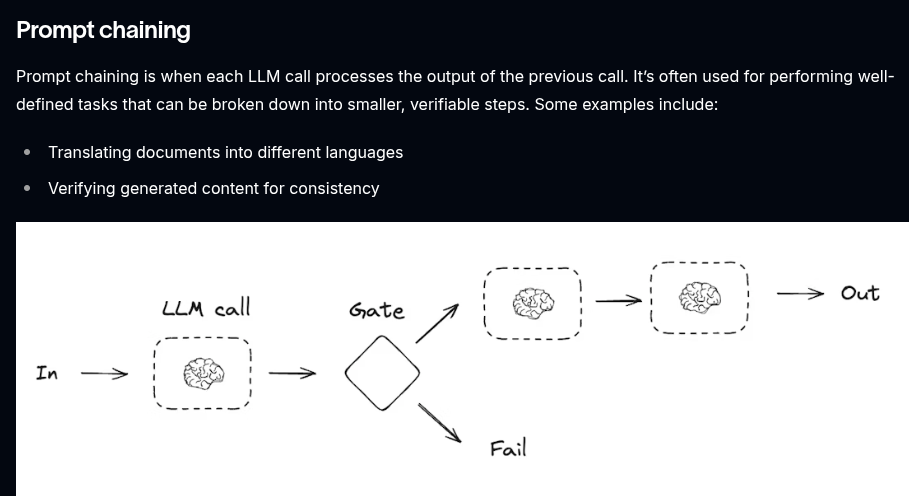

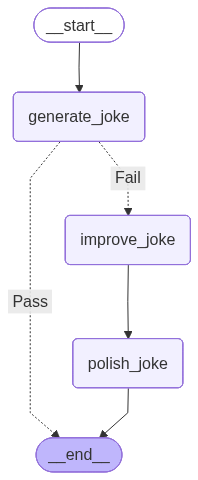

Initial joke:
Why did the cat sit in front of the computer?

Because it wanted to keep an eye on the mouse!

--- --- ---

Final joke:
Why did the cat sit in front of the computer?

Because it wanted to keep an eye on the mouse!


In [21]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

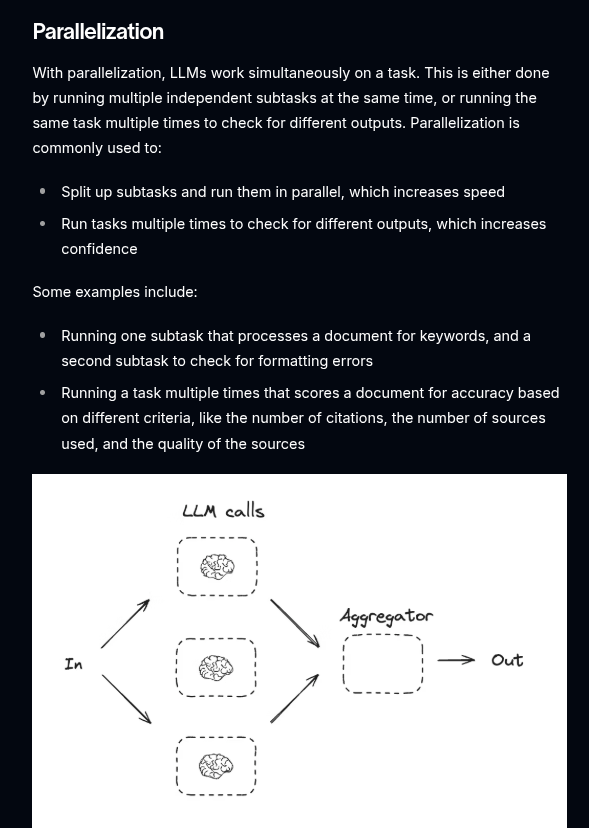

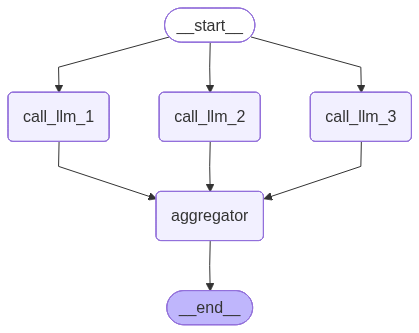

Here's a story, joke, and poem about cats!

STORY:
Once upon a time, in a quaint little town, there lived a woman named Mrs. Thompson who had a special love for cats. She had seven cats of her own, each with their own unique personalities and quirks.

The first cat was named Whiskers, a fluffy white Persian cat who loved nothing more than to curl up in Mrs. Thompson's lap and purr contentedly. Whiskers was a gentle soul, always eager to please and showered with affection.

The second cat was named Luna, a sleek black cat with bright yellow eyes. Luna was a mischievous creature, always getting into trouble and causing chaos around the house. Despite her antics, Mrs. Thompson couldn't help but adore her little troublemaker.

The third cat was named Oliver, a ginger tomcat with a feisty personality. Oliver was a fearless hunter, always bringing Mrs. Thompson gifts of mice and birds as if he were providing for the family. Though his gifts were not always appreciated, Mrs. Thompson loved Ol

In [22]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

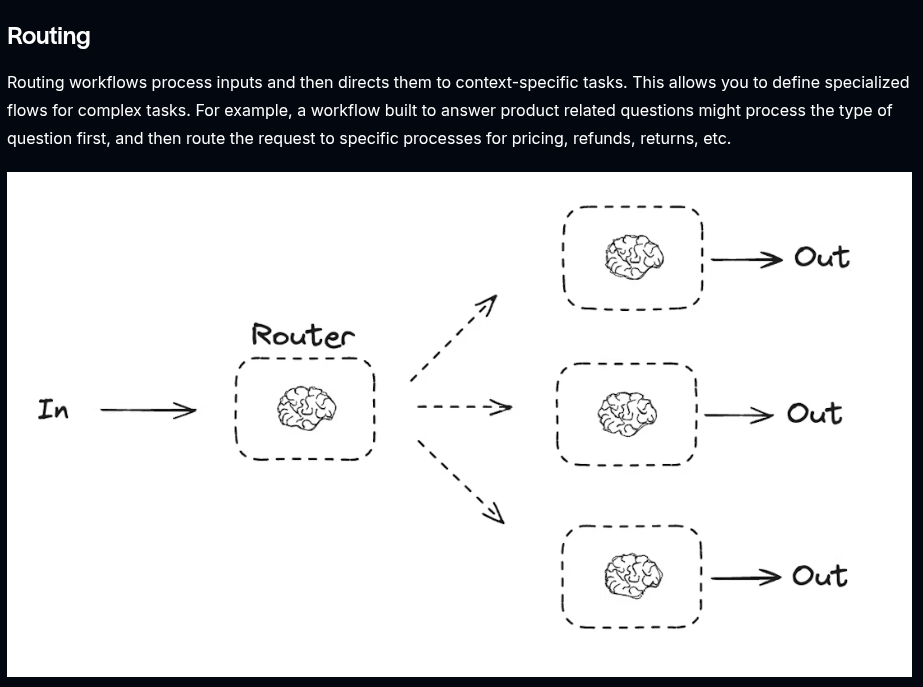

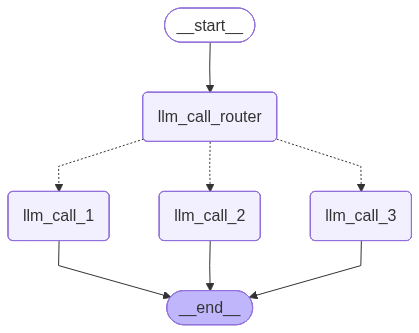

Why did the dog sit in the shade? 

Because he didn't want to be a hot dog!


In [27]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about dogs"})
print(state["output"])

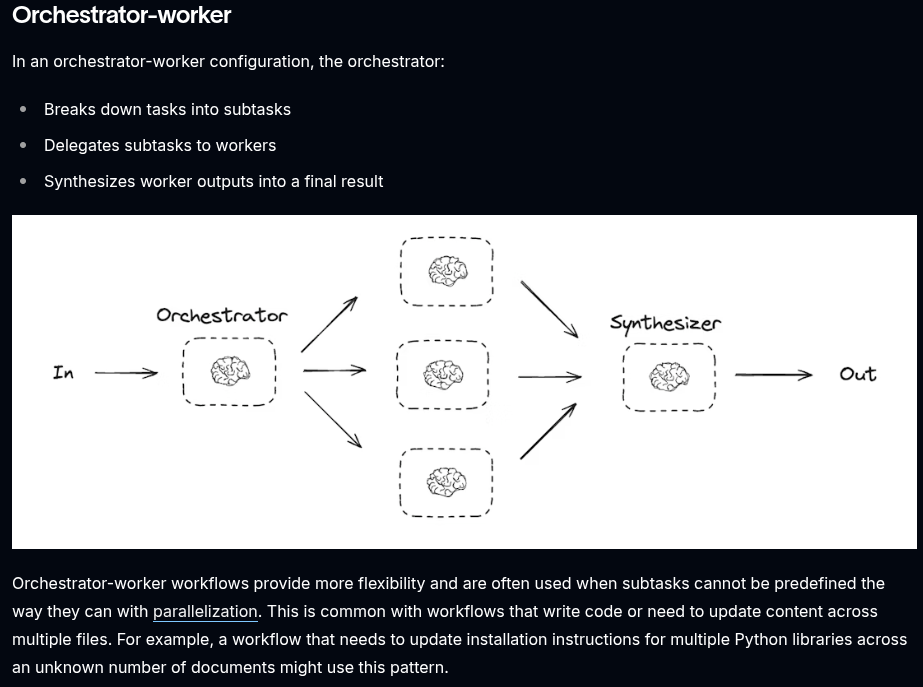

In [41]:
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

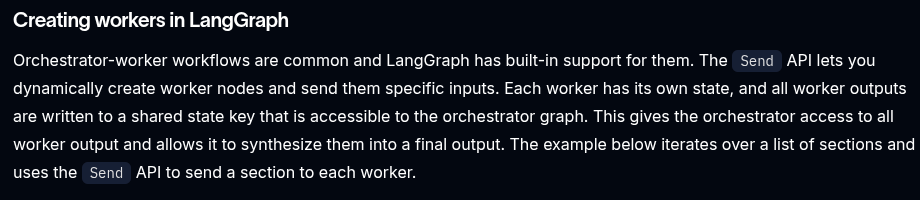

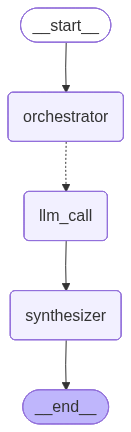

## Introduction

LLM scaling laws are mathematical relationships that describe how certain properties or behaviors of a system scale as a function of its size. These scaling laws are often observed in various fields such as physics, biology, and economics, among others. Understanding LLM scaling laws is crucial as it allows researchers to make predictions about the behavior of systems at different scales, without having to directly measure or observe them at all scales. This concept has profound implications for our understanding of complex systems and their dynamics.

---

## Explanation of LLM Scaling Laws

LLM scaling laws are mathematical relationships that describe how certain properties or characteristics of a system change with scale. These laws help in understanding the behavior of complex systems across different sizes and can be applied in various domains to predict outcomes or optimize processes.

### Examples of LLM Scaling Laws in Different Domains:

1. **Biology:** In biology, allometric scaling laws are used to study the relationship between the size of an organism and its metabolic rate. These laws help in understanding how metabolic processes scale with body size in animals.
   
2. **Engineering:** In structural engineering, scaling laws are utilized to design structures that are stable and safe at different sizes. For example, the strength of materials needed for a bridge can be calculated using scaling laws based on the size and weight the bridge needs to support.
   
3. **Ecology:** Scaling laws are applied in ecology to understand the relationship between the size of a habitat and the species diversity it can support. By studying how different ecological variables scale with area or volume, researchers can make predictions about biodiversity patterns in different ecosystems.

These examples illustrate how LLM scaling laws provide valuable insights into the behavior of systems across various disciplines and help in making informed decisions based on scale-dependent relationships.

---

### Applications of LLM Scaling Laws

LLM scaling laws have been extensively used across various industries to gain insights into complex phenomena and optimize processes. In aerospace, these laws play a crucial role in predicting the behavior of aerodynamic flows and designing efficient aircraft structures. The ability to accurately scale models based on LLM principles has enabled engineers to perform cost-effective testing and simulate real-world conditions.

In material science, LLM scaling laws are fundamental in studying the mechanical properties of materials at different scales. By understanding how properties change with size, researchers can develop novel materials with tailored characteristics, such as improved strength or flexibility. This knowledge is invaluable in industries where materials play a critical role, such as manufacturing and construction.

Furthermore, in biology, LLM scaling laws help biologists and researchers to understand biological systems from the cellular level to the organism level. By applying these laws, scientists can predict the metabolic rates, growth patterns, and physical characteristics of organisms, leading to advancements in areas like biotechnology, ecology, and medicine.

Overall, the applications of LLM scaling laws across these industries highlight the versatility and significance of scaling principles in solving complex problems and driving innovation.

---

### Limitations and Challenges

LLM scaling laws have several limitations and challenges that need to be addressed for their effective implementation. One of the main limitations is the assumption of perfect linearity in the scaling relationships, which may not always hold true in real-world systems due to factors such as non-linear dynamics and complex interactions. This can lead to inaccuracies in the predictions made using LLM scaling laws.

Another challenge is the sensitivity of the scaling laws to changes in parameters or inputs. Small variations in the data used to derive the scaling relationships can have a significant impact on the outcomes, making the predictions less reliable. This highlights the importance of ensuring the quality and consistency of data when applying LLM scaling laws.

Additionally, the generalizability of scaling laws across different domains or systems is a common challenge. It may not always be straightforward to transfer scaling relationships derived from one context to another, as the underlying mechanisms and dynamics can vary significantly. This calls for careful consideration and validation when extrapolating LLM scaling laws to new scenarios.

To mitigate these limitations and challenges, it is essential to validate scaling laws using empirical data and experimental observations. Robust validation studies can help improve the accuracy and reliability of the scaling relationships, making them more applicable to real-world scenarios. Sensitivity analyses can also be conducted to understand the impact of parameter variations and uncertainties on the predictions generated by LLM scaling laws.

Furthermore, incorporating domain knowledge and expert judgment can enhance the interpretation and application of scaling laws. By considering the underlying principles and assumptions of the scaling relationships, practitioners can make informed decisions and adjustments to improve the predictive power of LLM scaling laws. Overall, a cautious and data-driven approach is crucial for overcoming the limitations and challenges associated with LLM scaling laws.

---

## Conclusion

The LLM scaling laws play a crucial role in the research and development of various systems. By understanding these scaling laws, researchers and engineers can optimize the design and performance of systems. In this report, we discussed the key concepts of LLM scaling laws, including power scaling, frequency scaling, and size scaling. It is evident that a deep understanding of these scaling laws is essential for achieving efficient and effective design solutions. Moving forward, continued research and application of LLM scaling laws will be vital in driving innovation and progress in various fields of technology and engineering.

In [42]:
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on LLM scaling laws"})

from IPython.display import Markdown
Markdown(state["final_report"])

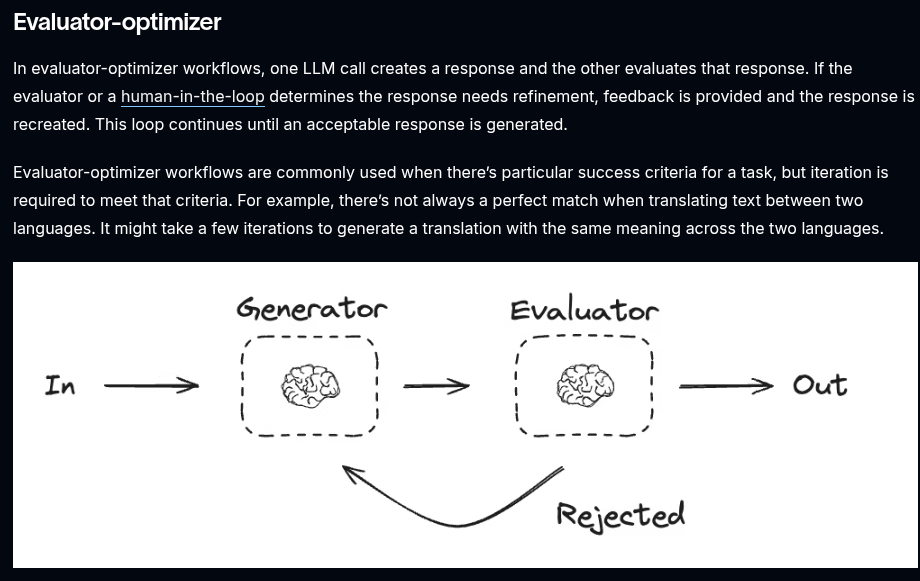

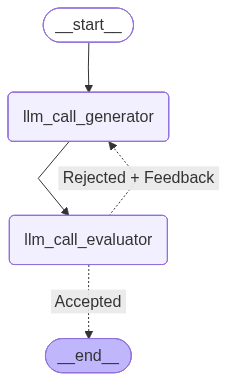

Why do programmers prefer dark mode?

Because the light hurts their eyes and they're afraid of seeing too many bugs!


In [47]:
# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    # return {"funny_or_not": grade.grade, "feedback": grade.feedback}
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = optimizer_workflow.invoke({"topic": "programming"})

print(state["joke"])

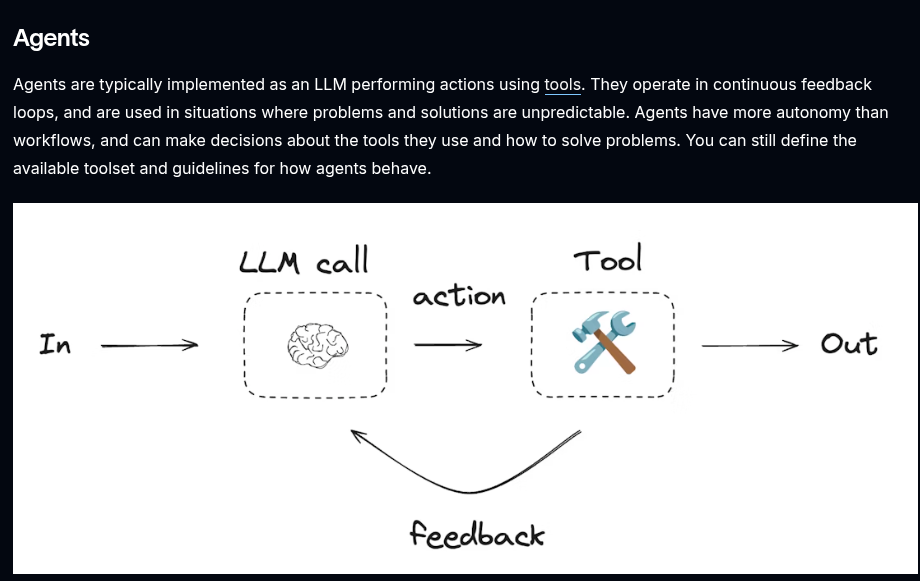

In [48]:
from langchain.tools import tool


# Define tools
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


# Augment the LLM with tools
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

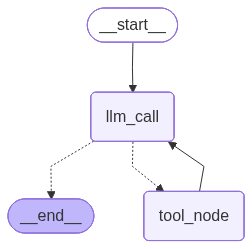

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_5hdwCAZUG4I9mVTQxEYzO6Nh)
 Call ID: call_5hdwCAZUG4I9mVTQxEYzO6Nh
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [49]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage


# Nodes
def llm_call(state: MessagesState):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ]
    }


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END


# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

### Capabilities

#### Persistence

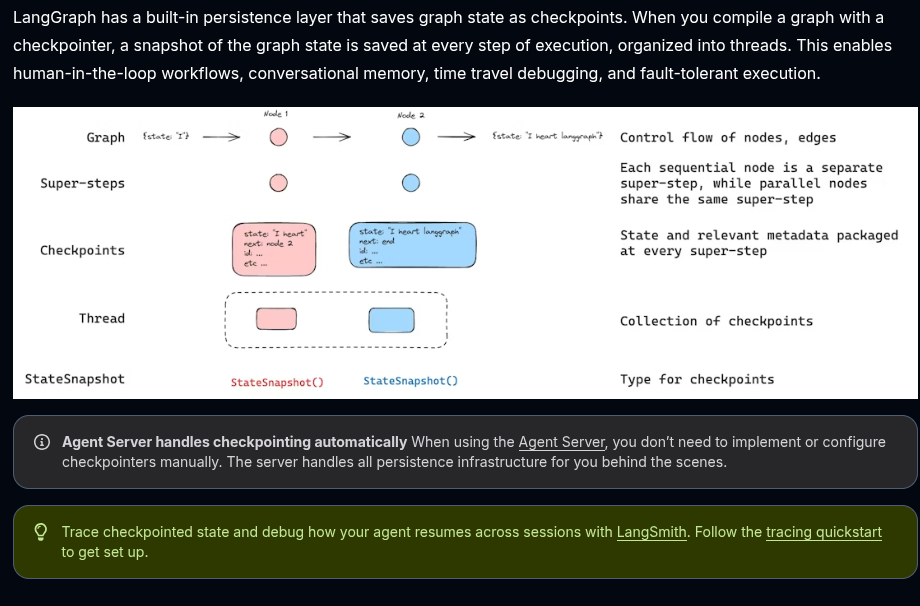

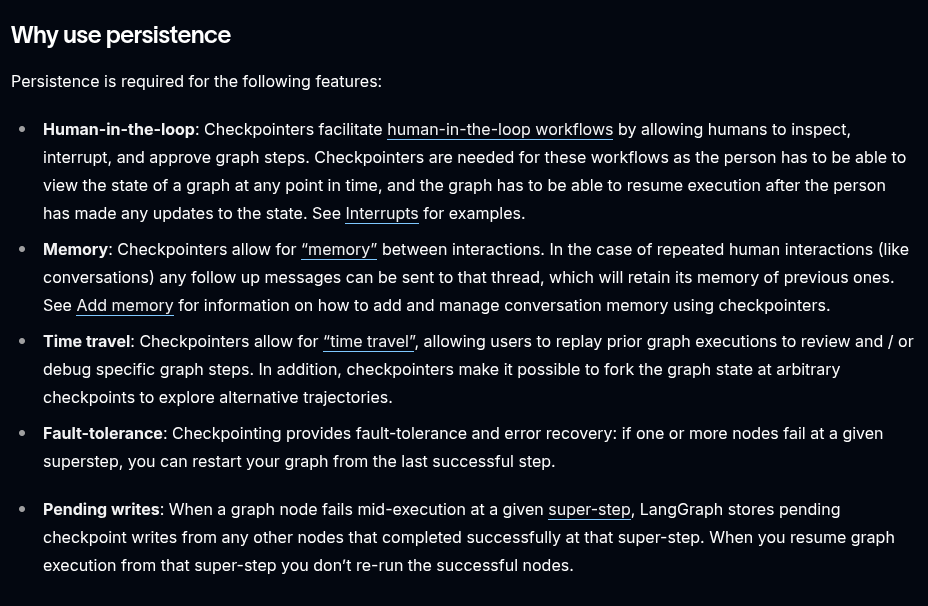

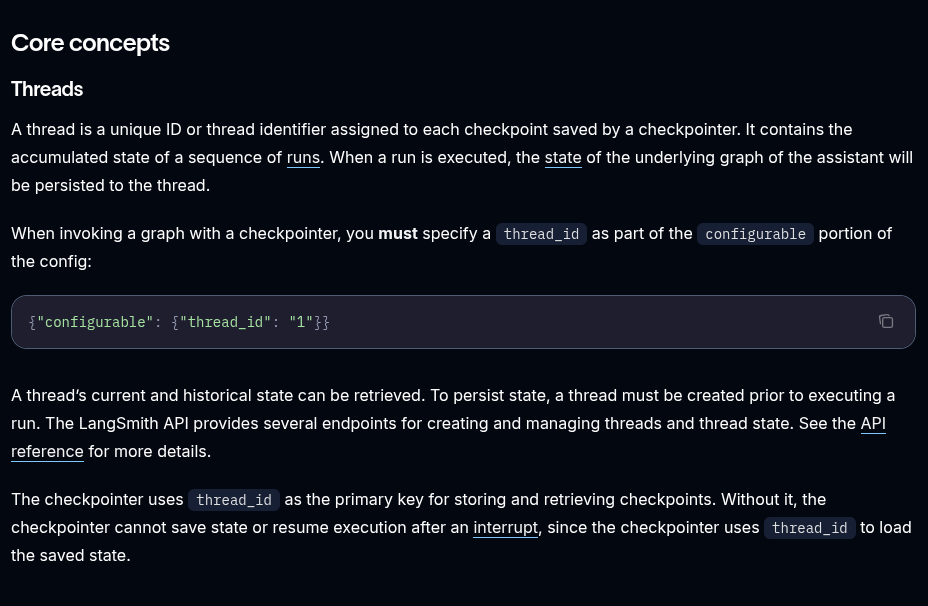

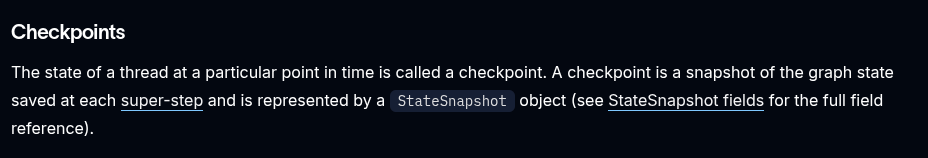

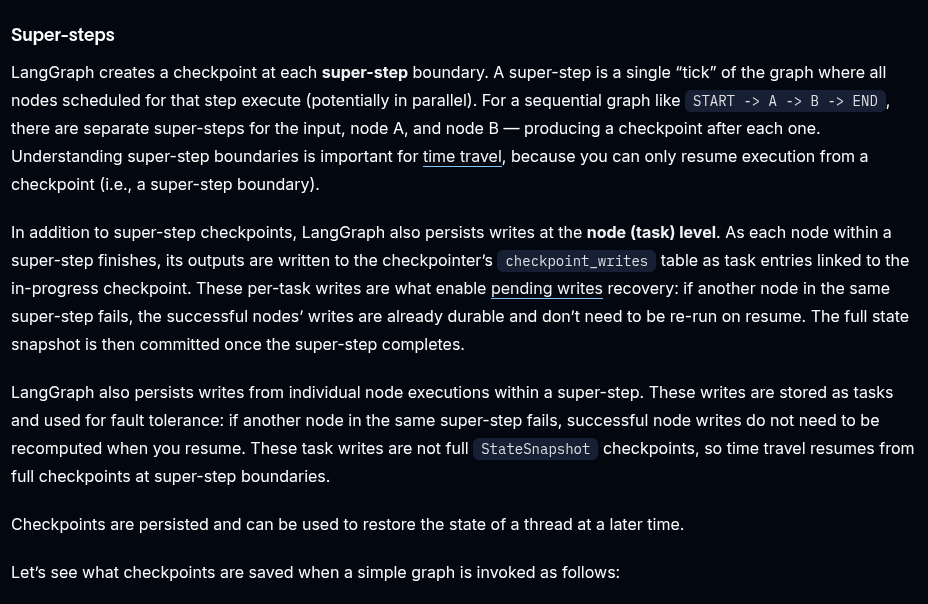

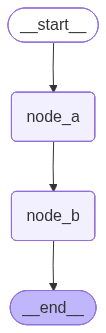

a: 
 {'foo': '', 'bar': []}
b: 
 {'foo': 'a', 'bar': ['a']}


{'foo': 'b', 'bar': ['a', 'b']}

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from IPython.display import Image 


class State(TypedDict):
    foo: str
    bar: Annotated[list[str], add]

def node_a(state: State):
    print('a: \n',state)
    return {"foo": "a", "bar": ["a"]}

def node_b(state: State):
    print('b: \n',state)
    return {"foo": "b", "bar": ["b"]}


workflow = StateGraph(State)
workflow.add_node(node_a)
workflow.add_node(node_b)
workflow.add_edge(START, "node_a")
workflow.add_edge("node_a", "node_b")
workflow.add_edge("node_b", END)

checkpointer = InMemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
graph.invoke({"foo": "", "bar":[]}, config)

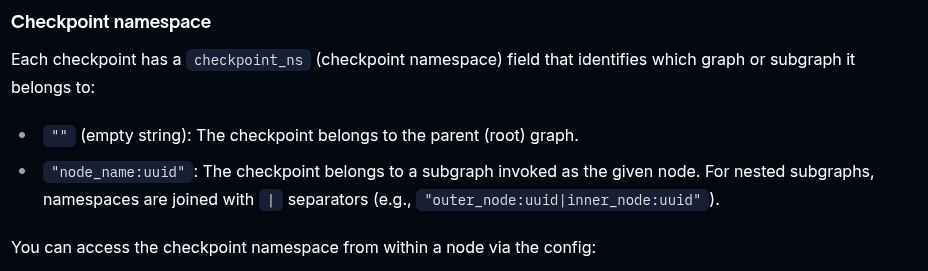

In [ ]:
config = {'configurable':{'thread_id':'1'}}
graph.get_state(config)
# write code to make the ouput easily readable


StateSnapshot(values={'foo': 'b', 'bar': ['a', 'b']}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f155d3a-bbaf-6b92-8002-4d1bf3a9c91c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-22T11:45:03.281440+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f155d3a-bbad-6769-8001-ad2ef5e448dc'}}, tasks=(), interrupts=())

In [6]:
config = {"configurable": {"thread_id": "1", "checkpoint_id": "1f155d3a-bbad-6769-8001-ad2ef5e448dc"}}
graph.get_state(config)

StateSnapshot(values={'foo': 'a', 'bar': ['a']}, next=('node_b',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f155d3a-bbad-6769-8001-ad2ef5e448dc'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-22T11:45:03.280514+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f155d3a-bbab-62c2-8000-8eec72769bbd'}}, tasks=(PregelTask(id='44b15255-3fed-8d44-2fe1-ea398b0afb0b', name='node_b', path=('__pregel_pull', 'node_b'), error=None, interrupts=(), state=None, result={'foo': 'b', 'bar': ['b']}),), interrupts=())